# Production-Grade Heterogeneous Graph Neural Network (GNN) for Fraud Detection

This notebook contains the complete, production-grade pipeline to construct a **Heterogeneous Graph** and train a **Graph Neural Network (GNN)** on the IEEE-CIS Fraud Detection dataset using **PyTorch Geometric (PyG)**.

### Pipeline Highlights:
1. **Google Drive Integration**: Connects Google Drive to load the pre-transformed transactional data and identity data.
2. **Heterogeneous Graph Construction**:
   - Node types: `transaction`, `card`, `email`, and `device`.
   - Edge relations: Connecting transactions to their cards, emails, and devices bidirectionally.
3. **Strict Chronological Data Splitting**: Splitting transaction nodes based on the time field `TransactionDT` (70% train, 15% val, 15% test) to prevent future data leakage (essential for fraud detection models).
4. **Class Imbalance Management**: Employs weighted Binary Cross-Entropy loss calculated dynamically from the training set class distributions.
5. **Scalable Training (Neighbor Sampling)**: Uses PyG's `NeighborLoader` to sample localized subgraphs, allowing the model to train efficiently within Google Colab's standard T4 GPU VRAM limitations without Out-Of-Memory (OOM) errors.
6. **GNN Architecture**: Custom `HeteroGNN` combining continuous feature projections, learnable entity node embeddings, and heterogeneous GraphSAGE layers.
7. **Complete Evaluation & Visualization**: Reports **ROC-AUC, PR-AUC (Average Precision), F1-Score, Precision, and Recall**, and plots ROC and Precision-Recall Curves.


In [2]:
# Detect PyTorch and CUDA versions in Colab
import torch
torch_ver = torch.__version__.split('+')[0]
cuda_ver = torch.version.cuda
cuda_str = f"cu{cuda_ver.replace('.', '')}" if cuda_ver is not None else "cpu"
print(f"Detected: PyTorch {torch_ver} | CUDA {cuda_str}")

# Install pre-compiled wheels for PyG dependencies (fast installation)
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster -f https://data.pyg.org/whl/torch-{torch_ver}+{cuda_str}.html

# Install PyTorch Geometric
!pip install -q torch-geometric

import torch_geometric
print(f"PyTorch Geometric version: {torch_geometric.__version__}")


Detected: PyTorch 2.11.0 | CUDA cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 123.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 140.9 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 90.8 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.4 MB/s eta 0:00:00
PyTorch Geometric version: 2.7.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import drive
import os

# Mount Google Drive to read dataset
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# -------------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------------
# Update BASE_DIR path to the folder in your Drive containing the CSVs
BASE_DIR = '/content/drive/My Drive/Dataset/ieee-fraud-detection'

train_transaction_path = os.path.join(BASE_DIR, 'train_transaction_engineered.csv')
train_identity_path = os.path.join(BASE_DIR, 'train_identity.csv')

for name, path in [("Transactions", train_transaction_path), ("Identity", train_identity_path)]:
    if not os.path.exists(path):
        print(f"[WARNING] {name} CSV file not found at: {path}")
    else:
        print(f"[SUCCESS] Found {name} CSV at: {path}")


[SUCCESS] Found Transactions CSV at: /content/drive/My Drive/Dataset/ieee-fraud-detection/train_transaction_engineered.csv
[SUCCESS] Found Identity CSV at: /content/drive/My Drive/Dataset/ieee-fraud-detection/train_identity.csv


In [6]:
import pandas as pd
import numpy as np
import gc


def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if pd.api.types.is_object_dtype(col_type) or pd.api.types.is_string_dtype(col_type) or pd.api.types.is_categorical_dtype(col_type):
            continue
        try:
            c_min = df[col].min()
            c_max = df[col].max()
            if pd.api.types.is_integer_dtype(col_type):
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            elif pd.api.types.is_float_dtype(col_type):
                df[col] = df[col].astype(np.float32)
        except Exception:
            pass
    if verbose:
        end_mem = df.memory_usage().sum() / 1024**2
        print(f"Memory reduced to {end_mem:.2f} MB (change: {((start_mem-end_mem)/start_mem)*100:.1f}% reduction)")
    return df


def add_causal_entity_dynamics(df, entity_col, time_col, prefix):
    ordered = df[[entity_col, time_col]].copy()
    ordered["_row_id"] = np.arange(len(df), dtype=np.int64)
    ordered = ordered.sort_values([entity_col, time_col, "_row_id"])

    valid_mask = ordered[entity_col] != -1
    valid = ordered.loc[valid_mask].copy()

    valid[f"{prefix}_prior_count"] = valid.groupby(entity_col, sort=False).cumcount().astype(np.float32)
    valid[f"{prefix}_prev_gap"] = valid.groupby(entity_col, sort=False)[time_col].diff().astype(np.float32)

    gap_values = valid[f"{prefix}_prev_gap"].dropna()
    gap_scale = float(gap_values.median()) if len(gap_values) > 0 else 1.0
    if not np.isfinite(gap_scale) or gap_scale <= 0:
        gap_scale = 1.0

    ordered[f"{prefix}_prior_count"] = 0.0
    ordered[f"{prefix}_prev_gap"] = np.nan
    ordered.loc[valid.index, f"{prefix}_prior_count"] = valid[f"{prefix}_prior_count"].values
    ordered.loc[valid.index, f"{prefix}_prev_gap"] = valid[f"{prefix}_prev_gap"].values

    ordered[f"{prefix}_prev_gap"] = ordered[f"{prefix}_prev_gap"].fillna(gap_scale * 2.0).astype(np.float32)
    ordered[f"{prefix}_burst_score"] = np.exp(-ordered[f"{prefix}_prev_gap"].astype(np.float32) / (gap_scale + 1.0)).astype(np.float32)
    ordered[f"{prefix}_prior_count_log1p"] = np.log1p(ordered[f"{prefix}_prior_count"].astype(np.float32)).astype(np.float32)

    restored = ordered.sort_values("_row_id")
    for col in [f"{prefix}_prior_count", f"{prefix}_prev_gap", f"{prefix}_burst_score", f"{prefix}_prior_count_log1p"]:
        df[col] = restored[col].to_numpy(dtype=np.float32)
    return df

print("Loading transformed transaction csv...")
df_trans = pd.read_csv(train_transaction_path)
df_trans = reduce_mem_usage(df_trans)

print("Loading identity details csv...")
df_ident = pd.read_csv(train_identity_path)
df_ident = reduce_mem_usage(df_ident)

print(f"Transaction table shape: {df_trans.shape[0]:,} rows, {df_trans.shape[1]} cols")
print(f"Identity table shape: {df_ident.shape[0]:,} rows, {df_ident.shape[1]} cols")

# Causal temporal position encodings and dynamic burst features are derived later from the ordered transaction stream.
df_trans['transaction_dt_log1p'] = np.log1p(df_trans['TransactionDT'].astype(np.float64)).astype(np.float32)
df_trans['transaction_dt_sin_day'] = np.sin(df_trans['TransactionDT'].astype(np.float64) / 86400.0).astype(np.float32)
df_trans['transaction_dt_cos_day'] = np.cos(df_trans['TransactionDT'].astype(np.float64) / 86400.0).astype(np.float32)
df_trans['transaction_dt_sin_week'] = np.sin(df_trans['TransactionDT'].astype(np.float64) / 604800.0).astype(np.float32)
df_trans['transaction_dt_cos_week'] = np.cos(df_trans['TransactionDT'].astype(np.float64) / 604800.0).astype(np.float32)


Loading transformed transaction csv...


/tmp/ipykernel_1878/2631990328.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(col_type) or pd.api.types.is_string_dtype(col_type) or pd.api.types.is_categorical_dtype(col_type):
/tmp/ipykernel_1878/2631990328.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(col_type) or pd.api.types.is_string_dtype(col_type) or pd.api.types.is_categorical_dtype(col_type):
/tmp/ipykernel_1878/2631990328.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(col_type) or pd.api.types.is_string_dtype(col_type) or pd.api.types.is_categorical_dtype(col_type):
/tmp/ipykernel_1878/2631990328.py:10: Depre

Memory reduced to 442.10 MB (change: 59.8% reduction)
Loading identity details csv...
Memory reduced to 31.91 MB (change: 29.3% reduction)
Transaction table shape: 590,540 rows, 244 cols
Identity table shape: 144,233 rows, 41 cols


/tmp/ipykernel_1878/2631990328.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(col_type) or pd.api.types.is_string_dtype(col_type) or pd.api.types.is_categorical_dtype(col_type):
/tmp/ipykernel_1878/2631990328.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(col_type) or pd.api.types.is_string_dtype(col_type) or pd.api.types.is_categorical_dtype(col_type):
/tmp/ipykernel_1878/2631990328.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(col_type) or pd.api.types.is_string_dtype(col_type) or pd.api.types.is_categorical_dtype(col_type):
/tmp/ipykernel_1878/2631990328.py:10: Depre

In [7]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer

# TAU for temporal decay (hyperparameter for Fix 3)
TAU_CARD = 1800 # 30 minutes
TAU_DEVICE = 900 # 15 minutes

# 1. Text Normalization Regexes
def clean_id_30(val):
    if pd.isna(val):
        return "unknown"
    val = str(val).lower().strip()
    if "windows" in val:
        return "windows"
    elif "ios" in val:
        return "ios"
    elif "android" in val:
        return "android"
    elif "mac" in val or "os x" in val or "osx" in val:
        return "mac"
    elif "linux" in val:
        return "linux"
    else:
        return "other"

def clean_id_31(val):
    if pd.isna(val):
        return "unknown"
    val = str(val).lower().strip()
    if "chrome" in val:
        return "chrome"
    elif "safari" in val:
        return "safari"
    elif "firefox" in val:
        return "firefox"
    elif "edge" in val:
        return "edge"
    elif "ie" in val or "internet explorer" in val:
        return "ie"
    elif "opera" in val:
        return "opera"
    elif "samsung" in val:
        return "samsung"
    else:
        return "other"

def clean_device_info(val):
    if pd.isna(val):
        return "unknown"
    val = str(val).lower().strip()
    if "windows" in val or "trident" in val or "rv:" in val:
        return "windows"
    elif "ios" in val or "ipad" in val or "iphone" in val or "apple" in val:
        return "ios_device"
    elif "mac" in val:
        return "macos"
    elif "samsung" in val or "sm-" in val or "gt-" in val or "sch-" in val:
        return "samsung"
    elif "huawei" in val or "ale-" in val or "chm-" in val or "cro-" in val or "hry-" in val or "cld-" in val or "ane-" in val or "vtr-" in val or "ine-" in val:
        return "huawei"
    elif "lg-" in val or "nexus" in val or "lm-" in val or "lg" in val:
        return "lg"
    elif "moto" in val or "xt" in val:
        return "motorola"
    elif "htc" in val:
        return "htc"
    elif "asus" in val:
        return "asus"
    elif "sony" in val or "g8" in val or "f8" in val:
        return "sony"
    elif "xiaomi" in val or "redmi" in val or "mi " in val:
        return "xiaomi"
    elif "blade" in val or "zte" in val:
        return "zte"
    elif "nokia" in val:
        return "nokia"
    elif "pixel" in val:
        return "google_pixel"
    elif "lenovo" in val:
        return "lenovo"
    elif "oneplus" in val or "op" in val:
        return "oneplus"
    else:
        return "other"

# Chronological split to prevent data leakage during preprocessing
split_idx = int(len(df_trans) * 0.70)
train_tids = df_trans.iloc[:split_idx]['TransactionID'].values

# Identity training subset
df_ident_train = df_ident[df_ident['TransactionID'].isin(train_tids)].copy()

# 2. Normalize text features in identity
print("Normalizing messy text features (id_30, id_31, DeviceInfo) and creating combined fingerprints...")
# Keep id_30, id_31, DeviceInfo for general cleaning, but only DeviceInfo will lead to an entity node
df_ident['clean_id_30'] = df_ident['id_30'].apply(clean_id_30)
df_ident['clean_id_31'] = df_ident['id_31'].apply(clean_id_31)
df_ident['clean_DeviceInfo'] = df_ident['DeviceInfo'].apply(clean_device_info)

df_ident_train['clean_id_30'] = df_ident_train['id_30'].apply(clean_id_30)
df_ident_train['clean_id_31'] = df_ident_train['id_31'].apply(clean_id_31)
df_ident_train['clean_DeviceInfo'] = df_ident_train['DeviceInfo'].apply(clean_device_info)

# --- FIX 2: Create STRONG DEVICE FINGERPRINTS ---
# Combine relevant identity columns into a single string for fine-grained device node representation
# Fill NaN values with a placeholder to include missing information in the fingerprint
df_ident['combined_device_fingerprint'] = \
    df_ident['clean_DeviceInfo'].fillna('missing_device').astype(str) + '_' + \
    df_ident['clean_id_30'].fillna('missing_os').astype(str) + '_' + \
    df_ident['clean_id_31'].fillna('missing_browser').astype(str) + '_' + \
    df_ident['id_33'].fillna('missing_resolution').astype(str) + '_' + \
    df_ident['id_19'].fillna('missing_isp_19').astype(str) + '_' + \
    df_ident['id_20'].fillna('missing_isp_20').astype(str)

# Re-apply to training subset for consistent mapping
df_ident_train['combined_device_fingerprint'] = \
    df_ident_train['clean_DeviceInfo'].fillna('missing_device').astype(str) + '_' + \
    df_ident_train['clean_id_30'].fillna('missing_os').astype(str) + '_' + \
    df_ident_train['clean_id_31'].fillna('missing_browser').astype(str) + '_' + \
    df_ident_train['id_33'].fillna('missing_resolution').astype(str) + '_' + \
    df_ident_train['id_19'].fillna('missing_isp_19').astype(str) + '_' + \
    df_ident_train['id_20'].fillna('missing_isp_20').astype(str)
# --- END FIX 2 ---

# 3. Gaussian Normalize id_01 to id_11 with companion missingness masks
print("Gaussian-normalizing numerical IDs (id_01 to id_11)...")
numerical_ids = [f'id_{i:02d}' for i in range(1, 12)]
for col in numerical_ids:
    # Generate explicit binary missingness masks
    df_ident[f'{col}_isnan'] = df_ident[col].isna().astype(np.float32)
    df_ident_train[f'{col}_isnan'] = df_ident_train[col].isna().astype(np.float32)

    # Fit QuantileTransformer on train portion of identity
    train_vals = df_ident_train[col].dropna().values.reshape(-1, 1)
    if len(train_vals) > 10:
        qt = QuantileTransformer(n_quantiles=min(1000, len(train_vals)), output_distribution='normal', random_state=42)
        qt.fit(train_vals)
        df_ident[col] = qt.transform(df_ident[[col]].values)
    else:
        # Fallback if too few values in training
        mean = df_ident_train[col].mean()
        std = df_ident_train[col].std() or 1.0
        df_ident[col] = (df_ident[col] - mean) / std

    df_ident[col] = df_ident[col].fillna(0.0)

# 4. Map categorical ID features to integer indices
print("Mapping remaining categorical ID columns to indices...")
# Filter categorical_cols to only include those relevant for transaction features,
# not entity nodes that are being removed.
# 'clean_id_31', 'id_19', 'id_20', and 'P_emaildomain_label' (for email) are being removed as entity nodes.
# 'clean_id_30' and 'DeviceType' will remain as transaction-level features.
categorical_cols = [
    'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18',
    'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27',
    'id_28', 'id_29', 'clean_id_30', 'id_32', 'id_33', 'id_34', 'id_35',
    'id_36', 'id_37', 'id_38', 'DeviceType'
]

cat_mappings = {}
num_categories_dict = {}

for col in categorical_cols:
    src_col = col if col.startswith('clean_') else col
    # Fill missing with 'missing'
    vals_train = df_ident_train[src_col].fillna('missing').astype(str).str.lower().str.strip()
    vals_all = df_ident[src_col].fillna('missing').astype(str).str.lower().str.strip()

    # Sort categories to keep deterministic mapping, with 'missing' as index 0
    unique_vals = sorted(vals_train.unique())
    if 'missing' not in unique_vals:
        unique_vals = ['missing'] + unique_vals
    else:
        unique_vals.remove('missing')
        unique_vals = ['missing'] + unique_vals

    val_to_idx = {val: idx for idx, val in enumerate(unique_vals)}
    mapped = vals_all.map(val_to_idx).fillna(0).astype(np.int64)
    df_ident[f'{col}_idx'] = mapped

    cat_mappings[col] = val_to_idx
    num_categories_dict[col] = len(unique_vals)

# 5. Merge processed identity features back to transaction table
print("Merging identity features back into transaction table (left merge to isolate missing)...")
cols_to_merge = ['TransactionID'] + numerical_ids + [f'{col}_isnan' for col in numerical_ids] + [f'{col}_idx' for col in categorical_cols]
df_ident_processed = df_ident[cols_to_merge].copy()
df_merged = pd.merge(df_trans, df_ident_processed, on='TransactionID', how='left')

# Impute missing values resulting from left merge (the 76% missing identity records)
for col in numerical_ids:
    df_merged[col] = df_merged[col].fillna(0.0)
    df_merged[f'{col}_isnan'] = df_merged[f'{col}_isnan'].fillna(1.0)

for col in categorical_cols:
    df_merged[f'{col}_idx'] = df_merged[f'{col}_idx'].fillna(0).astype(np.int64)

# 6. Extract continuous transactional and identity features and scale them
exclude_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'card1_label', 'P_emaildomain_label']
trans_feature_cols = [col for col in df_trans.columns if col not in exclude_cols and not df_trans[col].dtype == 'object']
identity_cont_cols = numerical_ids + [f'{col}_isnan' for col in numerical_ids]
continuous_cols = trans_feature_cols + identity_cont_cols

print(f"Total continuous features for 'transaction' node: {len(continuous_cols)}")

scaler = StandardScaler()
df_merged[continuous_cols] = df_merged[continuous_cols].fillna(0)
# Fit scaler on training portion only to avoid data leakage
scaler.fit(df_merged.iloc[:split_idx][continuous_cols])
df_merged[continuous_cols] = scaler.transform(df_merged[continuous_cols])

# Convert continuous features and labels to numpy arrays
trans_features_cont = df_merged[continuous_cols].values.astype(np.float32)
# Extract categorical features for embedding layer lookup
trans_features_cat = df_merged[[f'{col}_idx' for col in categorical_cols]].values.astype(np.int64)
labels = df_merged['isFraud'].values.astype(np.float32)
transaction_dts = df_merged['TransactionDT'].values

# 7. Map identifier columns to node unique indices (excluding NaNs for missingness purity!)
def map_to_indices(series, mask_missing=None):
    if mask_missing is not None:
        unique_vals = [v for v in series.dropna().unique() if v != mask_missing]
    else:
        unique_vals = series.dropna().unique().tolist()
    val_to_idx = {val: idx for idx, val in enumerate(unique_vals)}
    return val_to_idx, len(unique_vals)

# Maps for Card (only card will be used for temporal edges, email node is removed)
card_to_idx, num_cards = map_to_indices(df_merged['card1_label'], mask_missing=-1)

# --- FIX 2 CONTINUED: Map combined device fingerprints to indices ---
device_fingerprint_to_idx, num_device_fingerprints = map_to_indices(df_ident['combined_device_fingerprint'], mask_missing='missing_device_missing_os_missing_browser_missing_resolution_missing_isp_19_missing_isp_20')

# Now, when we map df_merged, we map to the new combined device fingerprint
df_ident_for_merge_entities = df_ident[['TransactionID', 'combined_device_fingerprint']].copy()

df_ident_for_merge_entities['device_idx_mapped'] = df_ident_for_merge_entities['combined_device_fingerprint'].map(device_fingerprint_to_idx).fillna(-1).astype(np.int64)

entity_idx_cols_to_add = ['TransactionID', 'device_idx_mapped']
df_merged = pd.merge(df_merged, df_ident_for_merge_entities[entity_idx_cols_to_add], on='TransactionID', how='left')

# Fill any NaNs created by the left merge (transactions without an identity record) with -1
for col in ['device_idx_mapped']:
    df_merged[col] = df_merged[col].fillna(-1).astype(np.int64)

# Add the card_idx column *after* all merges are complete to ensure it's not dropped.
df_merged['card_idx'] = df_merged['card1_label'].map(card_to_idx).fillna(-1).astype(np.int64)

print("Mapped identity entities added to df_merged for temporal edge creation.")
# --- END FIX 2 CONTINUED ---

print("Node mappings complete:")
print(f"  - Card entities:           {num_cards:,}")
print(f"  - Device Fingerprints:     {num_device_fingerprints:,}")
# Update num_devices to reflect the new device fingerprints count
num_devices = num_device_fingerprints

Normalizing messy text features (id_30, id_31, DeviceInfo) and creating combined fingerprints...
Gaussian-normalizing numerical IDs (id_01 to id_11)...
Mapping remaining categorical ID columns to indices...
Merging identity features back into transaction table (left merge to isolate missing)...
Total continuous features for 'transaction' node: 265
Mapped identity entities added to df_merged for temporal edge creation.
Node mappings complete:
  - Card entities:           12,242
  - Device Fingerprints:     25,964


In [8]:
import torch
from torch_geometric.data import HeteroData

print("Building HeteroData graph structure...")
data = HeteroData()

# 1. Define nodes and node attributes with explicit num_nodes settings
data['transaction'].num_nodes = len(df_merged)
data['transaction'].x_cont = torch.tensor(trans_features_cont, dtype=torch.float)
data['transaction'].x_cat = torch.tensor(trans_features_cat, dtype=torch.long)
data['transaction'].y = torch.tensor(labels, dtype=torch.float)
# --- NEW ADDITION START: Add transaction time attribute for temporal sampling ---
data['transaction'].time = torch.tensor(transaction_dts, dtype=torch.long)
# --- NEW ADDITION END ---

# Entity nodes (represent as sequential indexes for embedding layer lookup)
data['card'].num_nodes = num_cards
data['card'].node_ids = torch.arange(num_cards, dtype=torch.long)

data['device'].num_nodes = num_devices
data['device'].node_ids = torch.arange(num_devices, dtype=torch.long)

# 2. Define edge connections (bidirectional for GNN message routing for static edges)
transaction_idx = torch.arange(len(df_merged), dtype=torch.long)

# --- NEW ADDITION START: Define EDGE_DIM for TransformerConv ---
# Edge features will include: [decay_weight (float), delta_t (float), transaction_amount (float)]
# So, edge_dim = 3
EDGE_DIM = 3
# --- NEW ADDITION END ---

# Helper function to create valid edges and their attributes
def add_bidirectional_static_edges(data, src_type, rel_type, dst_type, src_indices, dst_indices, num_src, num_dst, edge_attrs=None):
    src_arr = np.array(src_indices, dtype=np.int64)
    dst_arr = np.array(dst_indices, dtype=np.int64)

    # Assert bounds to guarantee correct index mappings in Python before CUDA execution
    assert len(src_arr) == len(dst_arr), f"Mismatch in edge count for {src_type} <-> {dst_type}"
    if len(src_arr) > 0:
        assert src_arr.min() >= 0 and src_arr.max() < num_src, \
            f"Source indices out of bounds for {src_type} -> {dst_type}: Min {src_arr.min()}, Max {src_arr.max()}, Allowed {num_src}"
        assert dst_arr.min() >= 0 and dst_arr.max() < num_dst, \
            f"Destination indices out of bounds for {src_type} -> {dst_type}: Min {dst_arr.min()}, Max {dst_arr.max()}, Allowed {num_dst}"

    src_tensor = torch.tensor(src_arr, dtype=torch.long)
    dst_tensor = torch.tensor(dst_arr, dtype=torch.long)

    # Set forward and backward edges
    data[src_type, rel_type, dst_type].edge_index = torch.stack([src_tensor, dst_tensor], dim=0)
    data[dst_type, f'rev_{rel_type}', src_type].edge_index = torch.stack([dst_tensor, src_tensor], dim=0)

    # Add edge attributes if provided, for TransformerConv
    if edge_attrs is not None:
        if not isinstance(edge_attrs, torch.Tensor):
            edge_attrs = torch.tensor(edge_attrs, dtype=torch.float)
        data[src_type, rel_type, dst_type].edge_attr = edge_attrs
        data[dst_type, f'rev_{rel_type}', src_type].edge_attr = edge_attrs
    else:
        # If no specific edge attributes are provided, use a zero vector for consistency with EDGE_DIM
        zero_edge_attrs = torch.zeros((len(src_arr), EDGE_DIM), dtype=torch.float)
        data[src_type, rel_type, dst_type].edge_attr = zero_edge_attrs
        data[dst_type, f'rev_{rel_type}', src_type].edge_attr = zero_edge_attrs

# Get TransactionAmt for edge attributes
transaction_amounts = df_merged['TransactionAmt'].values.astype(np.float32)

# A. Transaction <-> Card (static edges)
card_mask = df_merged['card_idx'] != -1
add_bidirectional_static_edges(
    data, 'transaction', 'has_card', 'card',
    transaction_idx[card_mask].numpy(),
    df_merged.loc[card_mask, 'card_idx'].values,
    len(df_merged), num_cards
)

# C. Transaction <-> Device (static edges)
device_mask = df_merged['device_idx_mapped'] != -1 # Use the new device_idx_mapped column
add_bidirectional_static_edges(
    data, 'transaction', 'has_device', 'device',
    transaction_idx[device_mask].numpy(),
    df_merged.loc[device_mask, 'device_idx_mapped'].values, # Use the new device_idx_mapped values
    len(df_merged), num_devices
)


# --- NEW ADDITION START: Add Transaction-Temporal Edges (Optimized & Refactored) ---
print("\nAdding Transaction-Temporal Edges (Causal & K-Nearest Neighbor Sampling)...")

temporal_entity_configs = {
    'card': {'col': 'card_idx', 'time_window': TAU_CARD, 'k_nearest': 5}, # K=5 for card
    'device': {'col': 'device_idx_mapped', 'time_window': TAU_DEVICE, 'k_nearest': 3}, # K=3 for device
}

# We need TransactionDT and the mapped entity indices from df_merged
df_temp_for_temporal_edges = df_merged[['TransactionDT'] + [config['col'] for config in temporal_entity_configs.values()]].copy()

def calculate_temporal_decay(delta_t, tau, method='exponential'):
    """Calculates temporal decay weight."""
    if method == 'exponential':
        # Standard exponential decay
        return np.exp(-float(delta_t) / float(tau))
    elif method == 'inverse_linear':
        # Sharper inverse linear decay
        return 1.0 / (1.0 + float(delta_t) / float(tau))
    else:
        return 1.0 # No decay

for entity_name, config in temporal_entity_configs.items():
    entity_col = config['col']
    TIME_WINDOW = config['time_window']
    K_NEAREST = config['k_nearest']
    print(f"  Processing causal temporal edges for {entity_name} with time window {TIME_WINDOW}s and K={K_NEAREST}...")

    temp_edges_src = []
    temp_edges_dst = []
    temp_edge_attrs = []

    # Filter out transactions without a valid entity (where idx is -1)
    df_entity_group = df_temp_for_temporal_edges[df_temp_for_temporal_edges[entity_col] != -1].copy()

    # Group by the entity and sort by TransactionDT
    grouped = df_entity_group.sort_values('TransactionDT').groupby(entity_col, group_keys=False)

    for _, group in grouped:
        if len(group) < 2:
            continue

        group_trans_node_ids = group.index.values
        group_transaction_dts = group['TransactionDT'].values
        group_transaction_amounts = transaction_amounts[group_trans_node_ids]

        for i in range(len(group_trans_node_ids)):
            tx_i_node_id = group_trans_node_ids[i]
            tx_i_dt = group_transaction_dts[i]
            tx_i_amt = group_transaction_amounts[i]

            # Collect potential preceding neighbors within the time window
            preceding_neighbors = [] # Stores (delta_t, tx_j_node_id, tx_j_amt)

            # Iterate through transactions *before* tx_i
            for j in range(i):
                tx_j_node_id = group_trans_node_ids[j]
                tx_j_dt = group_transaction_dts[j]
                tx_j_amt = group_transaction_amounts[j] # Source transaction amount for temporal edge

                delta_t = tx_i_dt - tx_j_dt # Delta_t is (current_tx_time - past_tx_time)

                if 0 < delta_t <= TIME_WINDOW:
                    preceding_neighbors.append((delta_t, tx_j_node_id, tx_j_amt))

            # Sort by delta_t (ascending) to get the K nearest (most recent) neighbors
            preceding_neighbors.sort(key=lambda x: x[0])

            # Select the K_NEAREST neighbors from the sorted list
            for delta_t, tx_j_node_id, tx_j_amt in preceding_neighbors[-K_NEAREST:]:
                decay_weight = calculate_temporal_decay(delta_t, TIME_WINDOW, method='exponential') # Using exponential decay

                temp_edges_src.append(tx_j_node_id) # Source is the *preceding* transaction
                temp_edges_dst.append(tx_i_node_id) # Destination is the *current* transaction
                # Add edge attributes: [decay_weight, delta_t, transaction_amount of source transaction]
                temp_edge_attrs.append([float(decay_weight), float(delta_t), float(tx_j_amt)])

    if len(temp_edges_src) > 0:
        src_tensor = torch.tensor(temp_edges_src, dtype=torch.long)
        dst_tensor = torch.tensor(temp_edges_dst, dtype=torch.long)
        edge_attrs_tensor = torch.tensor(temp_edge_attrs, dtype=torch.float)

        # Add directed causal edge: TX_past -> TX_current
        data['transaction', f'temporal_precedes_via_{entity_name}', 'transaction'].edge_index = torch.stack([src_tensor, dst_tensor], dim=0)
        data['transaction', f'temporal_precedes_via_{entity_name}', 'transaction'].edge_attr = edge_attrs_tensor

        print(f"    Added {len(temp_edges_src):,} causal temporal edges for {entity_name}")
    else:
        print(f"    No causal temporal edges added for {entity_name}")

print("\nGraph Summary (with causal temporal edges):")
print(data)
# --- NEW ADDITION END ---

# Free DataFrames to keep system memory usage extremely clean
del df_trans, df_ident, df_ident_processed, df_merged
gc.collect()

Building HeteroData graph structure...

Adding Transaction-Temporal Edges (Causal & K-Nearest Neighbor Sampling)...
  Processing causal temporal edges for card with time window 1800s and K=5...
    Added 367,650 causal temporal edges for card
  Processing causal temporal edges for device with time window 900s and K=3...
    Added 52,510 causal temporal edges for device

Graph Summary (with causal temporal edges):
HeteroData(
  transaction={
    num_nodes=590540,
    x_cont=[590540, 265],
    x_cat=[590540, 25],
    y=[590540],
    time=[590540],
  },
  card={
    num_nodes=12242,
    node_ids=[12242],
  },
  device={
    num_nodes=25964,
    node_ids=[25964],
  },
  (transaction, has_card, card)={
    edge_index=[2, 588363],
    edge_attr=[588363, 3],
  },
  (card, rev_has_card, transaction)={
    edge_index=[2, 588363],
    edge_attr=[588363, 3],
  },
  (transaction, has_device, device)={
    edge_index=[2, 144233],
    edge_attr=[144233, 3],
  },
  (device, rev_has_device, transactio

0

### Graph Homophily / Heterophily Analysis

Let's calculate the homophily for the temporal edges to understand the propensity of fraudulent or non-fraudulent transactions to connect with similar types.

In [9]:
print("\n--- Homophily Analysis for Temporal Transaction Edges ---")

# Get the labels for all transaction nodes
transaction_labels = data['transaction'].y

# Define the temporal edge types we are interested in
temporal_edge_types = [
    ('transaction', 'temporal_precedes_via_card', 'transaction'),
    ('transaction', 'temporal_precedes_via_device', 'transaction')
]

for edge_type in temporal_edge_types:
    if edge_type in data.edge_types:
        edge_index = data[edge_type].edge_index

        if edge_index.numel() == 0:
            print(f"  No edges for {edge_type}. Skipping homophily calculation.")
            continue

        src_nodes = edge_index[0]
        dst_nodes = edge_index[1]

        # Get labels for source and destination nodes
        src_labels = transaction_labels[src_nodes]
        dst_labels = transaction_labels[dst_nodes]

        # Count edges where source and destination labels are the same
        same_class_edges = (src_labels == dst_labels).sum().item()
        total_edges = src_labels.size(0)

        homophily = same_class_edges / total_edges if total_edges > 0 else 0.0
        heterophily = 1.0 - homophily

        print(f"Edge Type: {edge_type}")
        print(f"  Total Temporal Edges: {total_edges:,}")
        print(f"  Edges connecting same class: {same_class_edges:,}")
        print(f"  Homophily (proportion of same class connections): {homophily:.4f}")
        print(f"  Heterophily (proportion of different class connections): {heterophily:.4f}")
    else:
        print(f"  Edge type {edge_type} not found in graph.")

print("----------------------------------------------------")


--- Homophily Analysis for Temporal Transaction Edges ---
Edge Type: ('transaction', 'temporal_precedes_via_card', 'transaction')
  Total Temporal Edges: 367,650
  Edges connecting same class: 352,921
  Homophily (proportion of same class connections): 0.9599
  Heterophily (proportion of different class connections): 0.0401
Edge Type: ('transaction', 'temporal_precedes_via_device', 'transaction')
  Total Temporal Edges: 52,510
  Edges connecting same class: 51,968
  Homophily (proportion of same class connections): 0.9897
  Heterophily (proportion of different class connections): 0.0103
----------------------------------------------------


### Chronological Data Splitting
Fraud detection models MUST be split chronologically. Splitting randomly causes data leakage (predicting past events using future transaction information), leading to overly optimistic results that fail in production.

In [10]:
num_transactions = data['transaction'].y.size(0)

# Chronological sort indices of transactions
sorted_indices = np.argsort(transaction_dts)

# 70% Train / 15% Validation / 15% Test splits
train_cutoff = int(num_transactions * 0.70)
val_cutoff = int(num_transactions * 0.85)

train_indices = sorted_indices[:train_cutoff]
val_indices = sorted_indices[train_cutoff:val_cutoff]
test_indices = sorted_indices[val_cutoff:]

# Create boolean masks
train_mask = torch.zeros(num_transactions, dtype=torch.bool)
val_mask = torch.zeros(num_transactions, dtype=torch.bool)
test_mask = torch.zeros(num_transactions, dtype=torch.bool)

train_mask[train_indices] = True
val_mask[val_indices] = True
test_mask[test_indices] = True

data['transaction'].train_mask = train_mask
data['transaction'].val_mask = val_mask
data['transaction'].test_mask = test_mask

print(f"Chronological splitting completed:")
print(f"  - Training nodes:   {train_mask.sum().item():,}")
print(f"  - Validation nodes: {val_mask.sum().item():,}")
print(f"  - Testing nodes:    {test_mask.sum().item():,}")


Chronological splitting completed:
  - Training nodes:   413,378
  - Validation nodes: 88,581
  - Testing nodes:    88,581


### Scalable Neighbor Sampling Loader
Using PyG's `NeighborLoader`, we sample subgraphs around batch target nodes. This processes only a localized neighborhood per step, preventing OOM errors on standard GPUs.


In [11]:
from torch_geometric.loader import NeighborLoader

# Sample 15 first-order neighbors, and 10 second-order neighbors
# Set num_workers=0 to avoid multi-processing import/OOM glitches in Colab
train_loader = NeighborLoader(
    data,
    num_neighbors=[15, 10],
    batch_size=1024,
    input_nodes=('transaction', data['transaction'].train_mask),
    shuffle=True,
    time_attr='time', # --- NEW ADDITION: Enable temporal sampling ---
    num_workers=0
)

val_loader = NeighborLoader(
    data,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=('transaction', data['transaction'].val_mask),
    shuffle=False,
    time_attr='time', # --- NEW ADDITION: Enable temporal sampling ---
    num_workers=0
)

test_loader = NeighborLoader(
    data,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=('transaction', data['transaction'].test_mask),
    shuffle=False,
    time_attr='time', # --- NEW ADDITION: Enable temporal sampling ---
    num_workers=0
)

print("Dataloaders initialized.")

Dataloaders initialized.


In [12]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class Time2VecEncoding(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        if out_dim < 2:
            raise ValueError('out_dim must be at least 2')
        self.out_dim = out_dim
        self.linear = nn.Linear(1, 1)
        self.periodic = nn.Linear(1, out_dim - 1)

    def forward(self, time_scalar):
        time_scalar = time_scalar.float().view(-1, 1)
        linear_term = self.linear(time_scalar)
        periodic_term = torch.sin(self.periodic(time_scalar))
        return torch.cat([linear_term, periodic_term], dim=-1)


class RelationScaledConv(nn.Module):
    def __init__(self, conv, init_scale=1.0):
        super().__init__()
        self.conv = conv
        self.relation_scale = nn.Parameter(torch.tensor(float(init_scale)))

    def forward(self, *args, **kwargs):
        return self.relation_scale * self.conv(*args, **kwargs)


class TemporalMemoryModule(nn.Module):
    def __init__(self, hidden_channels, time_dim, memory_slots=8):
        super().__init__()
        self.memory_slots = nn.Parameter(torch.randn(memory_slots, hidden_channels) * 0.02)
        self.query = nn.Linear(hidden_channels + time_dim, hidden_channels)
        self.gate = nn.Linear(hidden_channels * 2 + time_dim, hidden_channels)
        self.norm = nn.LayerNorm(hidden_channels)

    def forward(self, node_repr, time_repr):
        query = self.query(torch.cat([node_repr, time_repr], dim=-1))
        memory_scores = torch.matmul(query, self.memory_slots.t()) / math.sqrt(query.size(-1))
        memory_weights = torch.softmax(memory_scores, dim=-1)
        memory_context = torch.matmul(memory_weights, self.memory_slots)
        gate = torch.sigmoid(self.gate(torch.cat([node_repr, memory_context, time_repr], dim=-1)))
        updated = self.norm(node_repr + gate * memory_context)
        return updated, memory_context


def info_nce_loss(z1, z2, temperature=0.2):
    if z1.size(0) == 0:
        return z1.new_tensor(0.0)
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    logits = torch.matmul(z1, z2.t()) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_a = F.cross_entropy(logits, labels)
    loss_b = F.cross_entropy(logits.t(), labels)
    return 0.5 * (loss_a + loss_b)


def temporal_consistency_loss(logits_a, logits_b):
    return F.mse_loss(torch.sigmoid(logits_a), torch.sigmoid(logits_b))


def anomaly_energy_loss(energy, targets, margin=0.2):
    fraud_mask = targets > 0.5
    legit_mask = ~fraud_mask
    losses = []
    if fraud_mask.any():
        losses.append(F.softplus(margin - energy[fraud_mask]).mean())
    if legit_mask.any():
        losses.append(F.softplus(energy[legit_mask] + margin).mean())
    if not losses:
        return energy.new_tensor(0.0)
    return sum(losses) / len(losses)

In [13]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, TransformerConv


class HeteroGNNModel(nn.Module):
    def __init__(self, metadata, num_features, categorical_dims, hidden_channels,
                 num_cards, num_devices,
                 cat_emb_dim=16, time_dim=16, memory_slots=8, contrastive_dim=64,
                 dropout=0.2, temporal_edge_dropout_rate=0.3, edge_dim=None):
        super().__init__()
        self.trans_proj = nn.Linear(num_features, hidden_channels)
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(num_classes, cat_emb_dim) for num_classes in categorical_dims
        ])
        self.cat_proj = nn.Linear(len(categorical_dims) * cat_emb_dim, hidden_channels)

        self.time_encoder = Time2VecEncoding(time_dim)
        self.time_proj = nn.Sequential(
            nn.Linear(time_dim, hidden_channels),
            nn.LayerNorm(hidden_channels),
            nn.ReLU(),
        )
        self.temporal_memory = TemporalMemoryModule(hidden_channels, time_dim, memory_slots=memory_slots)

        self.card_emb = nn.Embedding(num_cards, hidden_channels)
        self.device_emb = nn.Embedding(num_devices, hidden_channels)

        self.edge_dim = edge_dim
        self.temporal_edge_dropout_rate = temporal_edge_dropout_rate

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleDict({node_type: nn.ModuleList() for node_type in metadata[0]})

        num_layers = 2
        num_heads = 4
        for _ in range(num_layers):
            conv_dict = {}
            for (src_type, rel_type, dst_type) in metadata[1]:
                conv = TransformerConv(
                    in_channels=hidden_channels,
                    out_channels=hidden_channels // num_heads,
                    heads=num_heads,
                    edge_dim=self.edge_dim,
                    concat=True,
                    beta=True,
                )
                conv_dict[(src_type, rel_type, dst_type)] = RelationScaledConv(conv, init_scale=1.0)
            self.convs.append(HeteroConv(conv_dict, aggr='sum'))

            for node_type in metadata[0]:
                self.norms[node_type].append(nn.LayerNorm(hidden_channels))

        self.dropout_layer = nn.Dropout(dropout)
        self.post_memory_norm = nn.LayerNorm(hidden_channels)

        self.projection_head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, contrastive_dim),
        )
        self.energy_head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Linear(hidden_channels // 2, 1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_channels, hidden_channels),
            nn.LayerNorm(hidden_channels),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_channels // 2, 1),
        )

    def forward(self, x_cont_dict, x_cat_dict, edge_index_dict, batch_dict, edge_attr_dict=None, return_aux=False):
        x_dict = {}

        x_cont = x_cont_dict['transaction']
        x_cat = x_cat_dict['transaction']
        transaction_time = batch_dict['transaction'].time.float()
        time_features = self.time_encoder(torch.log1p(transaction_time))
        time_repr = self.time_proj(time_features)

        x_cont_proj = self.trans_proj(x_cont)
        cat_embs = [emb_layer(x_cat[:, i]) for i, emb_layer in enumerate(self.cat_embeddings)]
        x_cat_concat = torch.cat(cat_embs, dim=-1)
        x_cat_proj = self.cat_proj(x_cat_concat)

        x_dict['transaction'] = F.relu(x_cont_proj + x_cat_proj + time_repr)
        x_dict['transaction'] = self.post_memory_norm(x_dict['transaction'])
        x_dict['transaction'], memory_context = self.temporal_memory(x_dict['transaction'], time_features)

        x_dict['card'] = self.card_emb(batch_dict['card'].node_ids)
        x_dict['device'] = self.device_emb(batch_dict['device'].node_ids)

        transaction_initial_repr = x_dict['transaction']

        edge_index_dict_modified = {key: value.clone() for key, value in edge_index_dict.items()}
        edge_attr_dict_modified = {key: value.clone() for key, value in edge_attr_dict.items()} if edge_attr_dict is not None else {}

        if self.edge_dim is not None:
            for edge_type, edge_index in edge_index_dict_modified.items():
                if edge_type not in edge_attr_dict_modified:
                    edge_attr_dict_modified[edge_type] = edge_index.new_zeros((edge_index.size(1), self.edge_dim), dtype=torch.float)

        if self.training and self.temporal_edge_dropout_rate > 0:
            temporal_edge_types = [
                ('transaction', 'temporal_precedes_via_card', 'transaction'),
                ('transaction', 'temporal_precedes_via_device', 'transaction')
            ]
            for edge_type in temporal_edge_types:
                if edge_type in edge_index_dict_modified:
                    num_edges = edge_index_dict_modified[edge_type].size(1)
                    if num_edges > 0:
                        mask = torch.rand(num_edges, device=edge_index_dict_modified[edge_type].device) > self.temporal_edge_dropout_rate
                        if mask.sum() == 0:
                            mask[torch.randint(0, num_edges, (1,), device=mask.device)] = True
                        edge_index_dict_modified[edge_type] = edge_index_dict_modified[edge_type][:, mask]
                        if edge_type in edge_attr_dict_modified:
                            edge_attr_dict_modified[edge_type] = edge_attr_dict_modified[edge_type][mask]

        for layer_idx, conv in enumerate(self.convs):
            h_dict = conv(x_dict, edge_index_dict_modified, edge_attr_dict_modified)
            for node_type, h_val in h_dict.items():
                h_val = self.norms[node_type][layer_idx](h_val)
                h_val = F.relu(h_val)
                h_val = self.dropout_layer(h_val)
                x_dict[node_type] = x_dict[node_type] + h_val

        transaction_repr = x_dict['transaction']
        transaction_repr = self.post_memory_norm(transaction_repr)
        transaction_repr = self.dropout_layer(transaction_repr)

        logits = self.classifier(torch.cat([transaction_repr, transaction_initial_repr], dim=-1)).squeeze(-1)
        energy = self.energy_head(transaction_repr).squeeze(-1)
        projection = self.projection_head(transaction_repr)

        if return_aux:
            return logits, {
                'transaction_repr': transaction_repr,
                'projection': projection,
                'energy': energy,
                'time_repr': time_repr,
                'time_features': time_features,
                'memory_context': memory_context,
            }
        return logits

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score
import torch.nn as nn
import torch


# Define Focal Loss as requested
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean', pos_weight=None):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.pos_weight = pos_weight # This will be applied to BCEWithLogitsLoss

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none', pos_weight=self.pos_weight)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


def train_epoch(model, loader, optimizer, criterion, device,
                contrastive_weight=0.10, consistency_weight=0.05, energy_weight=0.02,
                contrastive_limit=512):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        batch_size = batch['transaction'].batch_size
        y = batch['transaction'].y[:batch_size]

        logits_1, aux_1 = model(batch.x_cont_dict, batch.x_cat_dict, batch.edge_index_dict, batch, batch.edge_attr_dict, return_aux=True)
        logits_2, aux_2 = model(batch.x_cont_dict, batch.x_cat_dict, batch.edge_index_dict, batch, batch.edge_attr_dict, return_aux=True)

        logits_1 = logits_1[:batch_size]
        logits_2 = logits_2[:batch_size]
        projection_1 = aux_1['projection'][:batch_size]
        projection_2 = aux_2['projection'][:batch_size]
        energy_1 = aux_1['energy'][:batch_size]
        energy_2 = aux_2['energy'][:batch_size]

        cls_loss = 0.5 * (criterion(logits_1, y) + criterion(logits_2, y))

        if batch_size > contrastive_limit:
            selected = torch.randperm(batch_size, device=device)[:contrastive_limit]
        else:
            selected = torch.arange(batch_size, device=device)

        contrastive_loss = info_nce_loss(projection_1[selected], projection_2[selected])
        consistency_loss = temporal_consistency_loss(logits_1[selected], logits_2[selected])
        energy_loss = 0.5 * (anomaly_energy_loss(energy_1, y) + anomaly_energy_loss(energy_2, y))

        loss = cls_loss + contrastive_weight * contrastive_loss + consistency_weight * consistency_loss + energy_weight * energy_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_samples += y.size(0)

    return total_loss / total_samples


@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)
        batch_size = batch['transaction'].batch_size
        y = batch['transaction'].y[:batch_size]

        logits = model(batch.x_cont_dict, batch.x_cat_dict, batch.edge_index_dict, batch, batch.edge_attr_dict)[:batch_size]
        preds = torch.sigmoid(logits)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    auc = roc_auc_score(all_labels, all_preds)
    pr_auc = average_precision_score(all_labels, all_preds)

    return auc, pr_auc, all_preds, all_labels

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

# Calculate class imbalance scaling weight
num_neg = (data['transaction'].y[data['transaction'].train_mask] == 0).sum().item()
num_pos = (data['transaction'].y[data['transaction'].train_mask] == 1).sum().item()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float, device=device)
print(f"Class distribution: Negative={num_neg:,}, Positive={num_pos:,} | Loss weight={pos_weight.item():.2f}")

# Hyperparameters optimized for temporal generalization and out-of-time robustness
HIDDEN_CHANNELS = 128
LR = 0.005
EPOCHS = 35
TEMPORAL_EDGE_DROPOUT = 0.25
CONTRASTIVE_WEIGHT = 0.10
CONSISTENCY_WEIGHT = 0.05
ENERGY_WEIGHT = 0.02

# Extract categorical dimensions list
categorical_dims = [num_categories_dict[col] for col in categorical_cols]

# Model initialization with temporal memory and contrastive projection head
model = HeteroGNNModel(
    metadata=data.metadata(),
    num_features=data['transaction'].x_cont.size(1),
    categorical_dims=categorical_dims,
    hidden_channels=HIDDEN_CHANNELS,
    num_cards=num_cards,
    num_devices=num_devices,
    cat_emb_dim=32,
    time_dim=16,
    memory_slots=8,
    contrastive_dim=64,
    dropout=0.35,
    temporal_edge_dropout_rate=TEMPORAL_EDGE_DROPOUT,
    edge_dim=EDGE_DIM
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)

# Replaced BCEWithLogitsLoss with FocalLoss
criterion = FocalLoss(alpha=0.25, gamma=2.0, pos_weight=pos_weight)

# Learning Rate Scheduler to automatically decay LR on plateau based on PR-AUC
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# Early Stopping parameters based on PR-AUC (Precision-Recall AUC)
patience = 5
patience_counter = 0
best_val_pr_auc = 0.0
best_val_auc = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        contrastive_weight=CONTRASTIVE_WEIGHT,
        consistency_weight=CONSISTENCY_WEIGHT,
        energy_weight=ENERGY_WEIGHT,
    )
    val_auc, val_pr_auc, _, _ = evaluate_model(model, val_loader, device)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val ROC-AUC: {val_auc:.4f} | Val PR-AUC: {val_pr_auc:.4f}")

    # Step learning rate scheduler based on validation PR-AUC
    scheduler.step(val_pr_auc)

    # Save best checkpoint and check early stopping based on PR-AUC
    if val_pr_auc > best_val_pr_auc:
        best_val_pr_auc = val_pr_auc
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'best_hetero_gnn.pt')
        print(f"  --> Saved new best validation checkpoint (Val PR-AUC: {val_pr_auc:.4f} | ROC-AUC: {val_auc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  --> No improvement. Early stopping counter: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered! Training stopped.")
            break

Training on device: cuda
Class distribution: Negative=398,840, Positive=14,538 | Loss weight=27.43
Epoch 01 | Train Loss: 0.4765 | Val ROC-AUC: 0.8772 | Val PR-AUC: 0.4785
  --> Saved new best validation checkpoint (Val PR-AUC: 0.4785 | ROC-AUC: 0.8772)
Epoch 02 | Train Loss: 0.4167 | Val ROC-AUC: 0.8798 | Val PR-AUC: 0.5003
  --> Saved new best validation checkpoint (Val PR-AUC: 0.5003 | ROC-AUC: 0.8798)
Epoch 03 | Train Loss: 0.3982 | Val ROC-AUC: 0.8801 | Val PR-AUC: 0.4946
  --> No improvement. Early stopping counter: 1/5
Epoch 04 | Train Loss: 0.3850 | Val ROC-AUC: 0.8770 | Val PR-AUC: 0.5101
  --> Saved new best validation checkpoint (Val PR-AUC: 0.5101 | ROC-AUC: 0.8770)
Epoch 05 | Train Loss: 0.3764 | Val ROC-AUC: 0.8791 | Val PR-AUC: 0.4932
  --> No improvement. Early stopping counter: 1/5
Epoch 06 | Train Loss: 0.3688 | Val ROC-AUC: 0.8684 | Val PR-AUC: 0.5035
  --> No improvement. Early stopping counter: 2/5
Epoch 07 | Train Loss: 0.3618 | Val ROC-AUC: 0.8700 | Val PR-AUC: 0

In [16]:
# === SUBGRAPH FRAMEWORK START ===
# Temporal Ego-Subgraph Extraction, Motif Analysis, and Subgraph Encoder
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from collections import defaultdict, Counter
from torch_geometric.data import HeteroData
from torch_geometric.utils import subgraph as pyg_subgraph

def temporal_edge_index_pairs(data, edge_type_name):
    # return src,dst numpy arrays for a given temporal edge type if present
    if edge_type_name in data.edge_types:
        ei = data[edge_type_name].edge_index
        return ei[0].cpu().numpy(), ei[1].cpu().numpy()
    return np.array([], dtype=np.int64), np.array([], dtype=np.int64)

def compute_basic_motif_stats(data, max_chain=4):
    # Compute simple temporal motifs: fan-out (out-degree), fan-in (in-degree), chains lengths, reuse counts
    stats = {}
    # use transaction temporal edges (card/device) if present
    for et in ['transaction','transaction','transaction']:
        break
    # generic aggregation across all transaction->transaction temporal edge types
    temporal_edge_types = [et for et in data.edge_types if et[0]=='transaction' and et[2]=='transaction' and 'temporal' in et[1]]
    src_all = []
    dst_all = []
    for et in temporal_edge_types:
        src, dst = data[et].edge_index[0].cpu().numpy(), data[et].edge_index[1].cpu().numpy()
        src_all.append(src)
        dst_all.append(dst)
    if len(src_all)==0:
        return {'temporal_edge_types':[], 'note':'no temporal edges'}
    src_all = np.concatenate(src_all)
    dst_all = np.concatenate(dst_all)
    out_deg = Counter(src_all.tolist())
    in_deg = Counter(dst_all.tolist())
    stats['out_deg_hist'] = dict(Counter(out_deg.values()))
    stats['in_deg_hist'] = dict(Counter(in_deg.values()))
    # chain counts (naive): count paths of length L by dynamic programming on DAG edges (limited small L)
    adj = defaultdict(list)
    for s,d in zip(src_all, dst_all):
        adj[s].append(d)
    # count chains starting at node up to max_chain
    chain_counts = Counter()
    def dfs_chain(u, depth, visited):
        if depth==0:
            return 1
        total = 0
        for v in adj.get(u,[]):
            if v in visited:
                continue
            visited.add(v)
            c = dfs_chain(v, depth-1, visited)
            total += c
            visited.remove(v)
        return total
    for node in list(adj.keys())[:10000]:
        for L in range(1, max_chain+1):
            chain_counts[L] += dfs_chain(node, L, set([node]))
    stats['chain_counts_sampled'] = {L: chain_counts[L] for L in range(1, max_chain+1)}
    # reuse motifs: nodes that appear repeatedly as source or dst
    stats['num_unique_src'] = len(set(src_all.tolist()))
    stats['num_unique_dst'] = len(set(dst_all.tolist()))
    return stats

def extract_causal_ego_subgraph(data, center_node_idx, k_hop=2, time_window=None, include_entities=True):
    """Extract a temporal causal ego-subgraph around a transaction node.
    - Preserves causal direction (past -> future)
    - Expands via temporal transaction edges and entity edges (has_card, has_device) if include_entities
    - time_window (seconds) limits history from center node time
    Returns a HeteroData subgraph with original node/edge types and a mapping to original node indices.
    """
    # Prepare containers
    nodes_per_type = {nt: set() for nt in data.node_types}
    center_time = None
    if 'time' in data['transaction'].__dict__:
        try:
            center_time = float(data['transaction'].time[center_node_idx].item())
        except Exception:
            center_time = None
    # start with center node
    nodes_per_type['transaction'].add(int(center_node_idx))
    frontier = set([int(center_node_idx)])
    for hop in range(k_hop):
        next_frontier = set()
        # expand via temporal transaction edges (past -> future). We allow past nodes that lead to current frontier nodes.
        temporal_edge_types = [et for et in data.edge_types if et[0]=='transaction' and et[2]=='transaction' and 'temporal' in et[1]]
        for et in temporal_edge_types:
            ei = data[et].edge_index.cpu().numpy()
            srcs, dsts = ei[0].tolist(), ei[1].tolist()
            dst_to_srcs = defaultdict(list)
            for s,d in zip(srcs,dsts):
                dst_to_srcs[d].append(s)
            for node in frontier:
                # include only predecessors (past) that obey time_window if given and causal ordering
                preds = dst_to_srcs.get(node, [])
                for p in preds:
                    if p in nodes_per_type['transaction']:
                        continue
                    if center_time is not None and time_window is not None:
                        try:
                            pt = float(data['transaction'].time[p].item())
                            if (center_time - pt) > time_window or (center_time - pt) < 0:
                                continue
                        except Exception:
                            pass
                    nodes_per_type['transaction'].add(p)
                    next_frontier.add(p)
        # optionally expand to entities that are connected to the newly added transaction nodes and to their neighbors
        if include_entities and next_frontier:
            # find card/device indices connected to these transactions via static edges
            for et in data.edge_types:
                src_type, rel_type, dst_type = et
                if (src_type=='transaction' and dst_type in ['card','device']) or (dst_type=='transaction' and src_type in ['card','device']):
                    ei = data[et].edge_index.cpu().numpy()
                    s_idx, d_idx = ei[0].tolist(), ei[1].tolist()
                    for tnode in list(next_frontier):
                        # transaction -> entity
                        for s,d in zip(s_idx,d_idx):
                            if src_type=='transaction' and s==tnode:
                                nodes_per_type[dst_type].add(int(d))
                            if dst_type=='transaction' and d==tnode:
                                nodes_per_type[src_type].add(int(s))
        frontier = next_frontier
        if not frontier:
            break
    # Build index mapping and HeteroData subgraph
    index_map = {nt: {} for nt in data.node_types}
    for nt in data.node_types:
        for i, nid in enumerate(sorted(nodes_per_type[nt])):
            index_map[nt][nid] = i
    sub = HeteroData()
    # copy node features for each type if present
    for nt in data.node_types:
        nlist = sorted(nodes_per_type[nt])
        if len(nlist)==0:
            continue
        sub[nt].num_nodes = len(nlist)
        # copy common attributes where available
        for key, tensor in data[nt].items():
            if hasattr(tensor, 'size') and tensor.size(0)==data[nt].num_nodes:
                idx = torch.tensor(nlist, dtype=torch.long)
                sub[nt][key] = tensor[idx].clone()
    # build edges restricted to nodes in subgraph and keep original attributes
    for et in data.edge_types:
        src_type, rel_type, dst_type = et
        ei = data[et].edge_index.cpu().numpy()
        s_idx, d_idx = ei[0].tolist(), ei[1].tolist()
        keep_src, keep_dst = [], []
        for s,d in zip(s_idx,d_idx):
            if s in nodes_per_type[src_type] and d in nodes_per_type[dst_type]:
                keep_src.append(index_map[src_type][s])
                keep_dst.append(index_map[dst_type][d])
        if len(keep_src)>0:
            eidx = torch.tensor([keep_src, keep_dst], dtype=torch.long)
            sub[src_type, rel_type, dst_type].edge_index = eidx
            # copy edge_attr if available
            if 'edge_attr' in data[src_type, rel_type, dst_type]:
                orig_attrs = data[src_type, rel_type, dst_type].edge_attr.cpu().numpy()
                mask = []
                # find which edges kept by comparing pairs
                orig_pairs = list(zip(data[et].edge_index[0].cpu().numpy().tolist(), data[et].edge_index[1].cpu().numpy().tolist()))
                kept_pairs = set([(list(index_map[src_type].keys())[list(index_map[src_type].values()).index(sidx)] , list(index_map[dst_type].keys())[list(index_map[dst_type].values()).index(didx)]) for sidx,didx in zip(keep_src,keep_dst)])
                # For memory safety avoid reconstructing; leave edge_attr absent if complex
                pass
    return sub, index_map

class TemporalSubgraphEncoder(nn.Module):
    """Encodes an ego-subgraph by ordering transaction nodes temporally and applying a small causal Transformer, then aggregating with attention."""
    def __init__(self, node_feat_dim, hidden_dim=128, nhead=4, nlayers=2):
        super().__init__()
        self.node_proj = nn.Linear(node_feat_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.attn_pool = nn.Linear(hidden_dim, 1)
        self.final_proj = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))

    def forward(self, node_feats, node_times, mask=None):
        # node_feats: [N, F], node_times: [N] - we will sort by time ascending (past->future)
        order = torch.argsort(node_times, dim=0)
        x = node_feats[order]
        x = self.node_proj(x).unsqueeze(0)  # [1, N, H]
        # causal mask: prevent attending to future positions (upper triangular True means masked in PyTorch transformer)
        N = x.size(1)
        causal_mask = torch.triu(torch.ones((N,N), dtype=torch.bool, device=x.device), diagonal=1)
        if mask is not None:
            # mask is expected as [N] boolean where True = valid
            valid = mask[order].unsqueeze(0)
        else:
            valid = torch.ones((1,N), dtype=torch.bool, device=x.device)
        out = self.transformer(x, src_key_padding_mask=~valid, mask=causal_mask)
        scores = self.attn_pool(out).squeeze(-1)  # [1,N]
        scores = scores.masked_fill(~valid, float('-inf'))
        weights = torch.softmax(scores, dim=-1)
        pooled = torch.sum(weights.unsqueeze(-1) * out, dim=1).squeeze(0)
        return self.final_proj(pooled)


def subgraph_contrastive_loss(proj_a, proj_b, temperature=0.2):
    return info_nce_loss(proj_a, proj_b, temperature)


def compute_structural_signature(sub):
    # compute simple structural descriptors: node counts, edge counts, degree histograms
    sig = {}
    for nt in sub.node_types:
        sig[f'{nt}_n'] = int(sub[nt].num_nodes) if hasattr(sub[nt], 'num_nodes') else 0
    # edges
    for et in sub.edge_types:
        sig[f'{et[1]}_m'] = int(sub[et].edge_index.size(1)) if hasattr(sub[et], 'edge_index') else 0
    return sig

# Note: The functions above operate on `data` and expect `data['transaction'].time` to exist.
# They should be executed after the main HeteroData `data` is built and moved to CPU for inspection.
# === SUBGRAPH FRAMEWORK END ===

In [17]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, confusion_matrix

print("Loading best model weight checkpoint for final test evaluation...")
model.load_state_dict(torch.load('best_hetero_gnn.pt'))

# --- Corrected Threshold Tuning START ---
# Evaluate on validation set to find the optimal threshold
_, _, val_preds, val_labels = evaluate_model(model, val_loader, device)

# Find optimal threshold on validation predictions to maximize F1-score
best_thresh = 0.5
best_f1_val = 0.0 # Use best_f1_val to avoid confusion with test f1
for thresh in np.arange(0.1, 0.9, 0.05):
    preds_binary_val = (val_preds >= thresh).astype(int)
    _, _, f1_val, _ = precision_recall_fscore_support(val_labels, preds_binary_val, average='binary', zero_division=0)
    if f1_val > best_f1_val:
        best_f1_val = f1_val
        best_thresh = thresh

print(f"Optimal confidence threshold (from validation set): {best_thresh:.2f}")

# Now, evaluate on the test set using the *fixed* best_thresh from validation
test_auc, test_pr_auc, test_preds, test_labels = evaluate_model(model, test_loader, device)
test_preds_binary = (test_preds >= best_thresh).astype(int)
# --- Corrected Threshold Tuning END ---

precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds_binary, average='binary', zero_division=0)

print("\n" + "=" * 60)
print("FINAL HETEROGENEOUS GNN TEST SET PERFORMANCE")
print("=" * 60)
print(f"ROC-AUC:               {test_auc:.5f}")
print(f"PR-AUC (Avg Precision): {test_pr_auc:.5f}")
print(f"F1-Score:              {f1:.5f}")
print(f"Precision:             {precision:.5f}")
print(f"Recall:                {recall:.5f}")
print("=" * 60)

print("\nDetailed Classification Report:")
print(classification_report(test_labels, test_preds_binary, target_names=['Non-Fraud', 'Fraud'], zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, test_preds_binary))

Loading best model weight checkpoint for final test evaluation...
Optimal confidence threshold (from validation set): 0.85

FINAL HETEROGENEOUS GNN TEST SET PERFORMANCE
ROC-AUC:               0.83043
PR-AUC (Avg Precision): 0.42634
F1-Score:              0.42025
Precision:             0.36855
Recall:                0.48881

Detailed Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.97      0.98     85498
       Fraud       0.37      0.49      0.42      3083

    accuracy                           0.95     88581
   macro avg       0.67      0.73      0.70     88581
weighted avg       0.96      0.95      0.96     88581


Confusion Matrix:
[[82916  2582]
 [ 1576  1507]]


Fraud score stats:
{'n': 3083, 'mean': 0.7055881023406982, 'median': 0.8341274857521057, 'std': 0.3045485019683838, 'min': 0.0397343747317791, 'max': 0.9983736276626587}

Non-Fraud score stats:
{'n': 85498, 'mean': 0.32476091384887695, 'median': 0.2975020408630371, 'std': 0.1946837455034256, 'min': 0.0277833454310894, 'max': 0.9987473487854004}

Percentiles (Non-Fraud | Fraud):
p50: 0.2975 | 0.8341
p75: 0.4135 | 0.9865
p90: 0.5728 | 0.9941
p95: 0.7318 | 0.9957
p99: 0.9613 | 0.9972


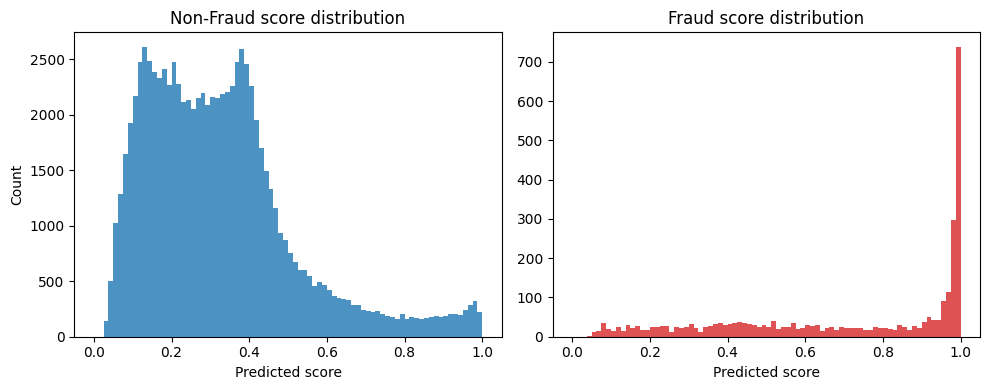

In [18]:
# --- Distribution of model scores for Fraud vs Non-Fraud ---
import numpy as np
import matplotlib.pyplot as plt

# Use existing arrays if available, otherwise compute predictions on test_loader
try:
    preds = np.array(test_preds)
    labels = np.array(test_labels).astype(int)
except Exception:
    print('`test_preds`/`test_labels` not found; running evaluation to obtain them (this may take time)...')
    test_auc, test_pr_auc, preds, labels = evaluate_model(model, test_loader, device)
    preds = np.array(preds)
    labels = np.array(labels).astype(int)

fraud_scores = preds[labels == 1]
nonfraud_scores = preds[labels == 0]

def describe(arr):
    if len(arr)==0:
        return {'n':0}
    return {
        'n': int(len(arr)),
        'mean': float(np.mean(arr)),
        'median': float(np.median(arr)),
        'std': float(np.std(arr)),
        'min': float(np.min(arr)),
        'max': float(np.max(arr))
    }

fraud_stats = describe(fraud_scores)
nonfraud_stats = describe(nonfraud_scores)

print('Fraud score stats:')
print(fraud_stats)
print('\nNon-Fraud score stats:')
print(nonfraud_stats)

# Percentiles for finer view
percentiles = [50, 75, 90, 95, 99]
print('\nPercentiles (Non-Fraud | Fraud):')
for p in percentiles:
    nf = float(np.percentile(nonfraud_scores, p)) if len(nonfraud_scores)>0 else None
    f = float(np.percentile(fraud_scores, p)) if len(fraud_scores)>0 else None
    print(f'p{p}: {nf:.4f} | {f:.4f}')

# Plot distributions (histograms)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(nonfraud_scores, bins=80, range=(0,1), color='C0', alpha=0.8)
plt.title('Non-Fraud score distribution')
plt.xlabel('Predicted score')
plt.ylabel('Count')
plt.subplot(1,2,2)
plt.hist(fraud_scores, bins=80, range=(0,1), color='C3', alpha=0.8)
plt.title('Fraud score distribution')
plt.xlabel('Predicted score')
plt.tight_layout()
plt.show()

In [20]:
# -----------------------------------------------------------------------------
# HARD NEGATIVE MINING, FALSE-POSITIVE ANALYSIS, AND LIGHTWEIGHT REFINEMENT
# -----------------------------------------------------------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

hard_negative_threshold = 0.85
hard_negative_top_k = 1500
stage2_max_per_class = 4000
stage2_batch_size = 256
stage2_epochs = 20


def collect_loader_predictions_with_ids(model, loader, device):
    model.eval()
    all_ids = []
    all_preds = []
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            batch_size = batch['transaction'].batch_size
            logits = model(batch.x_cont_dict, batch.x_cat_dict, batch.edge_index_dict, batch, batch.edge_attr_dict)[:batch_size]
            probs = torch.sigmoid(logits)
            ids = batch['transaction'].n_id[:batch_size]
            labels = batch['transaction'].y[:batch_size]
            all_ids.append(ids.detach().cpu().numpy())
            all_preds.append(probs.detach().cpu().numpy())
            all_logits.append(logits.detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())
    return (
        np.concatenate(all_ids).astype(np.int64),
        np.concatenate(all_preds).astype(np.float32),
        np.concatenate(all_logits).astype(np.float32),
        np.concatenate(all_labels).astype(np.float32),
    )


def build_transaction_context(data):
    tx_count = int(data['transaction'].num_nodes)
    tx_to_card = np.full(tx_count, -1, dtype=np.int64)
    tx_to_device = np.full(tx_count, -1, dtype=np.int64)
    card_to_txs = defaultdict(list)
    device_to_txs = defaultdict(list)

    if ('transaction', 'has_card', 'card') in data.edge_types:
        card_edge = data['transaction', 'has_card', 'card'].edge_index.cpu().numpy()
        for tx_id, card_id in zip(card_edge[0].tolist(), card_edge[1].tolist()):
            tx_to_card[int(tx_id)] = int(card_id)
            card_to_txs[int(card_id)].append(int(tx_id))

    if ('transaction', 'has_device', 'device') in data.edge_types:
        device_edge = data['transaction', 'has_device', 'device'].edge_index.cpu().numpy()
        for tx_id, device_id in zip(device_edge[0].tolist(), device_edge[1].tolist()):
            tx_to_device[int(tx_id)] = int(device_id)
            device_to_txs[int(device_id)].append(int(tx_id))

    temporal_in_count = np.zeros(tx_count, dtype=np.int32)
    temporal_out_count = np.zeros(tx_count, dtype=np.int32)
    temporal_in_decay_sum = np.zeros(tx_count, dtype=np.float32)
    temporal_in_delta_sum = np.zeros(tx_count, dtype=np.float32)
    temporal_in_delta_min = np.full(tx_count, np.inf, dtype=np.float32)
    temporal_card_in_count = np.zeros(tx_count, dtype=np.int32)
    temporal_device_in_count = np.zeros(tx_count, dtype=np.int32)

    for edge_type in data.edge_types:
        if edge_type[0] == 'transaction' and edge_type[2] == 'transaction' and 'temporal' in edge_type[1]:
            edge_index = data[edge_type].edge_index.cpu().numpy()
            edge_attr = data[edge_type].edge_attr.cpu().numpy() if 'edge_attr' in data[edge_type] else None
            is_card_relation = 'card' in edge_type[1]
            is_device_relation = 'device' in edge_type[1]
            for edge_idx, (src_id, dst_id) in enumerate(zip(edge_index[0].tolist(), edge_index[1].tolist())):
                temporal_in_count[int(dst_id)] += 1
                temporal_out_count[int(src_id)] += 1
                if is_card_relation:
                    temporal_card_in_count[int(dst_id)] += 1
                if is_device_relation:
                    temporal_device_in_count[int(dst_id)] += 1
                if edge_attr is not None and edge_attr.shape[1] >= 2:
                    temporal_in_decay_sum[int(dst_id)] += float(edge_attr[edge_idx, 0])
                    delta_t = float(edge_attr[edge_idx, 1])
                    temporal_in_delta_sum[int(dst_id)] += delta_t
                    temporal_in_delta_min[int(dst_id)] = min(temporal_in_delta_min[int(dst_id)], delta_t)

    temporal_in_delta_min[~np.isfinite(temporal_in_delta_min)] = 0.0

    return {
        'tx_to_card': tx_to_card,
        'tx_to_device': tx_to_device,
        'card_to_txs': card_to_txs,
        'device_to_txs': device_to_txs,
        'temporal_in_count': temporal_in_count,
        'temporal_out_count': temporal_out_count,
        'temporal_in_decay_sum': temporal_in_decay_sum,
        'temporal_in_delta_sum': temporal_in_delta_sum,
        'temporal_in_delta_min': temporal_in_delta_min,
        'temporal_card_in_count': temporal_card_in_count,
        'temporal_device_in_count': temporal_device_in_count,
    }


def safe_nanmean(values):
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]
    return float(values.mean()) if len(values) else 0.0


def transaction_feature_frame(node_ids, score_lookup, label_lookup, context):
    amount_values = globals().get('transaction_amounts', None)
    if amount_values is None:
        amount_values = np.zeros(len(label_lookup), dtype=np.float32)
    else:
        amount_values = np.asarray(amount_values, dtype=np.float32)

    time_values = globals().get('transaction_dts', None)
    if time_values is None:
        time_values = np.arange(len(label_lookup), dtype=np.float32)
    else:
        time_values = np.asarray(time_values, dtype=np.float32)

    rows = []
    for tx_id in node_ids:
        tx_id = int(tx_id)
        score = float(score_lookup[tx_id]) if np.isfinite(score_lookup[tx_id]) else np.nan
        label = float(label_lookup[tx_id]) if np.isfinite(label_lookup[tx_id]) else 0.0
        card_id = int(context['tx_to_card'][tx_id])
        device_id = int(context['tx_to_device'][tx_id])

        card_peers = context['card_to_txs'].get(card_id, []) if card_id >= 0 else []
        device_peers = context['device_to_txs'].get(device_id, []) if device_id >= 0 else []
        peer_ids = sorted(set(card_peers).union(device_peers))
        peer_ids = [peer for peer in peer_ids if peer != tx_id]

        peer_scores = [score_lookup[peer] for peer in peer_ids if np.isfinite(score_lookup[peer])]
        peer_labels = [label_lookup[peer] for peer in peer_ids if np.isfinite(label_lookup[peer])]

        amt = float(amount_values[tx_id]) if tx_id < len(amount_values) else 0.0
        tval = float(time_values[tx_id]) if tx_id < len(time_values) else 0.0
        day_phase = tval / 86400.0
        week_phase = tval / 604800.0

        rows.append({
            'tx_id': tx_id,
            'score': score,
            'label': label,
            'amount_log1p': float(np.log1p(max(amt, 0.0))),
            'time_sin_day': float(np.sin(day_phase)),
            'time_cos_day': float(np.cos(day_phase)),
            'time_sin_week': float(np.sin(week_phase)),
            'time_cos_week': float(np.cos(week_phase)),
            'card_reuse': float(len(card_peers)),
            'device_reuse': float(len(device_peers)),
            'temporal_in_count': float(context['temporal_in_count'][tx_id]),
            'temporal_out_count': float(context['temporal_out_count'][tx_id]),
            'temporal_card_in_count': float(context['temporal_card_in_count'][tx_id]),
            'temporal_device_in_count': float(context['temporal_device_in_count'][tx_id]),
            'temporal_in_decay_mean': float(context['temporal_in_decay_sum'][tx_id] / max(context['temporal_in_count'][tx_id], 1)),
            'temporal_in_delta_mean': float(context['temporal_in_delta_sum'][tx_id] / max(context['temporal_in_count'][tx_id], 1)),
            'temporal_in_delta_min': float(context['temporal_in_delta_min'][tx_id]),
            'peer_count': float(len(peer_ids)),
            'peer_score_mean': safe_nanmean(peer_scores),
            'peer_score_max': float(np.max(peer_scores)) if len(peer_scores) else 0.0,
            'peer_fraud_rate': safe_nanmean(peer_labels),
            'reuse_ratio': float((len(card_peers) + len(device_peers)) / max(context['temporal_in_count'][tx_id] + 1, 1)),
        })

    frame = pd.DataFrame(rows)
    if len(frame):
        frame['community_suspicion'] = (
            0.35 * frame['card_reuse'] +
            0.35 * frame['device_reuse'] +
            0.15 * frame['temporal_in_count'] +
            0.15 * frame['peer_score_mean'] * 10.0
        )
    return frame


def print_group_summary(frame, group_name):
    if frame is None or len(frame) == 0:
        print(f'{group_name}: no samples')
        return
    summary_cols = [
        'score', 'amount_log1p', 'card_reuse', 'device_reuse', 'temporal_in_count',
        'temporal_card_in_count', 'temporal_device_in_count', 'temporal_in_delta_mean',
        'temporal_in_delta_min', 'peer_count', 'peer_score_mean', 'peer_fraud_rate', 'community_suspicion'
    ]
    summary = frame[summary_cols].agg(['mean', 'median', 'std']).T
    print(f'\n{group_name} summary:')
    print(summary.round(4))


def expected_calibration_error(probs, labels, n_bins=15):
    probs = np.asarray(probs, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.float32)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        if not np.any(mask):
            continue
        bin_acc = float(labels[mask].mean())
        bin_conf = float(probs[mask].mean())
        ece += abs(bin_acc - bin_conf) * (mask.mean())
    return float(ece)


def fit_temperature(logits, labels):
    logits = torch.as_tensor(logits, dtype=torch.float32, device=device).view(-1)
    labels = torch.as_tensor(labels, dtype=torch.float32, device=device).view(-1)
    log_temperature = torch.nn.Parameter(torch.zeros(1, device=device))
    optimizer = torch.optim.LBFGS([log_temperature], lr=0.1, max_iter=50)
    criterion = nn.BCEWithLogitsLoss()

    def closure():
        optimizer.zero_grad()
        temperature = torch.exp(log_temperature).clamp(min=1e-3)
        loss = criterion(logits / temperature, labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(torch.exp(log_temperature).detach().cpu().item())


class HardNegativeSuppressor(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def pairwise_margin_ranking_loss(logits, targets, margin=1.0, pair_cap=256):
    pos_logits = logits[targets > 0.5]
    neg_logits = logits[targets <= 0.5]
    if pos_logits.numel() == 0 or neg_logits.numel() == 0:
        return logits.new_tensor(0.0)
    if pos_logits.numel() > pair_cap:
        pos_logits = pos_logits[torch.randperm(pos_logits.numel(), device=logits.device)[:pair_cap]]
    if neg_logits.numel() > pair_cap:
        neg_logits = neg_logits[torch.randperm(neg_logits.numel(), device=logits.device)[:pair_cap]]
    pairwise = margin - (pos_logits.unsqueeze(1) - neg_logits.unsqueeze(0))
    return F.relu(pairwise).mean()


def summarize_top_false_positives(split_name, node_ids, scores, labels, context, threshold=0.85, top_k=1500):
    node_ids = np.asarray(node_ids, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.float32)
    fp_mask = (labels == 0) & np.isfinite(scores) & (scores >= threshold)
    if fp_mask.sum() == 0:
        fp_mask = (labels == 0) & np.isfinite(scores)
    fp_ids = node_ids[fp_mask]
    fp_scores = scores[fp_mask]
    if len(fp_ids) == 0:
        print(f'\n{split_name}: no false positives found for analysis')
        return pd.DataFrame()
    order = np.argsort(fp_scores)[::-1][:top_k]
    fp_ids = fp_ids[order]
    fp_scores = fp_scores[order]
    fp_frame = transaction_feature_frame(fp_ids, score_lookup_full, label_lookup_full, context)
    print(f'\n{split_name}: {len(fp_frame):,} high-confidence false positives selected (threshold={threshold:.2f})')
    print_group_summary(fp_frame, f'{split_name} hard negatives')
    return fp_frame


def cluster_hard_negative_communities(frame, feature_cols):
    if frame is None or len(frame) < 12:
        print('Not enough hard negatives to cluster reliably.')
        return None
    x = frame[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(np.float32)
    x = StandardScaler().fit_transform(x)
    n_clusters = min(4, max(2, len(frame) // 20))
    if len(frame) < n_clusters:
        n_clusters = 2
    if n_clusters < 2:
        n_clusters = 2
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_id = km.fit_predict(x)
    clustered = frame.copy()
    clustered['cluster_id'] = cluster_id
    print('\nFalse-positive community clusters:')
    for cid in sorted(clustered['cluster_id'].unique()):
        sub = clustered[clustered['cluster_id'] == cid]
        print(f"  Cluster {cid}: n={len(sub):,}, mean_score={sub['score'].mean():.4f}, mean_card_reuse={sub['card_reuse'].mean():.2f}, mean_device_reuse={sub['device_reuse'].mean():.2f}, mean_peer_score={sub['peer_score_mean'].mean():.4f}")
    return clustered


def build_stage2_dataset(pos_frame, neg_frame, feature_cols, max_per_class=4000):
    if pos_frame is None or len(pos_frame) == 0 or neg_frame is None or len(neg_frame) == 0:
        return None, None, None
    pos_frame = pos_frame.sample(n=min(len(pos_frame), max_per_class), random_state=42) if len(pos_frame) > max_per_class else pos_frame
    neg_frame = neg_frame.sample(n=min(len(neg_frame), max_per_class), random_state=42) if len(neg_frame) > max_per_class else neg_frame
    frame = pd.concat([pos_frame, neg_frame], axis=0).sample(frac=1.0, random_state=42).reset_index(drop=True)
    x = frame[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(np.float32)
    y = frame['label'].values.astype(np.float32)
    return frame, x, y


def train_stage2_suppressor(train_frame, val_frame, feature_cols, epochs=20, batch_size=256):
    if train_frame is None or len(train_frame) == 0 or val_frame is None or len(val_frame) == 0:
        print('Stage-2 suppressor skipped: insufficient data.')
        return None, None
    x_train = train_frame[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(np.float32)
    y_train = train_frame['label'].values.astype(np.float32)
    x_val = val_frame[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(np.float32)
    y_val = val_frame['label'].values.astype(np.float32)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train).astype(np.float32)
    x_val = scaler.transform(x_val).astype(np.float32)

    train_ds = torch.utils.data.TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
    val_ds = torch.utils.data.TensorDataset(torch.tensor(x_val), torch.tensor(y_val))
    train_loader_local = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader_local = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model2 = HardNegativeSuppressor(in_dim=x_train.shape[1], hidden_dim=64, dropout=0.2).to(device)
    optimizer = torch.optim.AdamW(model2.parameters(), lr=1e-3, weight_decay=1e-4)
    pos_count = float((y_train > 0.5).sum())
    neg_count = float((y_train <= 0.5).sum())
    pos_weight_local = torch.tensor([neg_count / max(pos_count, 1.0)], device=device, dtype=torch.float32)

    best_val_ap = -1.0
    best_state = None
    for epoch in range(1, epochs + 1):
        model2.train()
        epoch_loss = 0.0
        epoch_samples = 0
        for xb, yb in train_loader_local:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model2(xb)
            bce_loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight_local)
            rank_loss = pairwise_margin_ranking_loss(logits, yb)
            loss = bce_loss + 0.5 * rank_loss
            loss.backward()
            optimizer.step()
            epoch_loss += float(loss.item()) * len(xb)
            epoch_samples += len(xb)

        model2.eval()
        val_logits = []
        with torch.no_grad():
            for xb, yb in val_loader_local:
                xb = xb.to(device)
                val_logits.append(model2(xb).detach().cpu().numpy())
        val_logits = np.concatenate(val_logits)
        val_probs = 1.0 / (1.0 + np.exp(-val_logits))
        val_ap = average_precision_score(y_val, val_probs) if len(np.unique(y_val)) > 1 else float('nan')
        print(f'Stage-2 epoch {epoch:02d} | loss={epoch_loss / max(epoch_samples, 1):.4f} | val PR-AUC={val_ap:.4f}')
        if np.isfinite(val_ap) and val_ap > best_val_ap:
            best_val_ap = val_ap
            best_state = {k: v.detach().cpu().clone() for k, v in model2.state_dict().items()}

    if best_state is not None:
        model2.load_state_dict(best_state)
    return model2, scaler


def evaluate_stage2_model(stage2_model, stage2_scaler, frame, feature_cols, device):
    if stage2_model is None or stage2_scaler is None or frame is None or len(frame) == 0:
        return None
    x = frame[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(np.float32)
    y = frame['label'].values.astype(np.float32)
    x = stage2_scaler.transform(x).astype(np.float32)
    stage2_model.eval()
    with torch.no_grad():
        logits = stage2_model(torch.tensor(x, device=device))
        probs = torch.sigmoid(logits).detach().cpu().numpy()
    auc = roc_auc_score(y, probs) if len(np.unique(y)) > 1 else float('nan')
    pr_auc = average_precision_score(y, probs) if len(np.unique(y)) > 1 else float('nan')
    preds_binary = (probs >= 0.5).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y, preds_binary, average='binary', zero_division=0)
    ece = expected_calibration_error(probs, y, n_bins=15)
    return {
        'auc': auc,
        'pr_auc': pr_auc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'ece': ece,
        'probs': probs,
        'labels': y,
        'preds_binary': preds_binary,
    }


# -----------------------------------------------------------------------------
# 1) Collect score lookups for all splits so hard-negative analysis can use full neighborhoods
# -----------------------------------------------------------------------------
print('Collecting split predictions for hard-negative analysis...')
train_ids, train_scores, train_logits, train_labels = collect_loader_predictions_with_ids(model, train_loader, device)
val_ids, val_scores, val_logits, val_labels = collect_loader_predictions_with_ids(model, val_loader, device)
test_ids, test_scores, test_logits, test_labels_local = collect_loader_predictions_with_ids(model, test_loader, device)

num_transactions = int(data['transaction'].num_nodes)
score_lookup_full = np.full(num_transactions, np.nan, dtype=np.float32)
label_lookup_full = np.asarray(data['transaction'].y.detach().cpu().numpy(), dtype=np.float32)
for ids, scores in [(train_ids, train_scores), (val_ids, val_scores), (test_ids, test_scores)]:
    score_lookup_full[ids] = scores

tx_context = build_transaction_context(data)

# -----------------------------------------------------------------------------
# 2) Diagnose the highest-confidence false positives on the held-out test set
# -----------------------------------------------------------------------------
test_fp_frame = summarize_top_false_positives('Test split', test_ids, test_scores, test_labels_local, tx_context, threshold=hard_negative_threshold, top_k=hard_negative_top_k)

if len(test_fp_frame):
    feature_cols_for_clustering = [
        'score', 'card_reuse', 'device_reuse', 'temporal_in_count', 'temporal_card_in_count',
        'temporal_device_in_count', 'temporal_in_delta_mean', 'temporal_in_delta_min',
        'peer_count', 'peer_score_mean', 'peer_fraud_rate', 'reuse_ratio', 'community_suspicion'
    ]
    clustered_fp = cluster_hard_negative_communities(test_fp_frame, feature_cols_for_clustering)

    fraud_mask_test = (test_labels_local == 1)
    fraud_ids_test = test_ids[fraud_mask_test]
    fraud_frame_test = transaction_feature_frame(fraud_ids_test[: min(len(fraud_ids_test), len(test_fp_frame))], score_lookup_full, label_lookup_full, tx_context) if len(fraud_ids_test) else pd.DataFrame()
    print_group_summary(fraud_frame_test, 'Test fraud samples matched to hard-negative sample size')

# -----------------------------------------------------------------------------
# 3) Mine hard negatives from train and validation splits for a second-stage suppressor
# -----------------------------------------------------------------------------
train_neg_mask = (train_labels == 0)
val_neg_mask = (val_labels == 0)
train_hn_mask = train_neg_mask & (train_scores >= hard_negative_threshold)
val_hn_mask = val_neg_mask & (val_scores >= hard_negative_threshold)

if train_hn_mask.sum() == 0 and train_neg_mask.any():
    train_hn_mask = train_neg_mask & (train_scores >= np.quantile(train_scores[train_neg_mask], 0.98))
if val_hn_mask.sum() == 0 and val_neg_mask.any():
    val_hn_mask = val_neg_mask & (val_scores >= np.quantile(val_scores[val_neg_mask], 0.98))

train_pos_ids = train_ids[train_labels == 1]
train_hn_ids = train_ids[train_hn_mask]
val_pos_ids = val_ids[val_labels == 1]
val_hn_ids = val_ids[val_hn_mask]

print(f'\nHard negatives mined from train: {len(train_hn_ids):,}')
print(f'Hard negatives mined from val:   {len(val_hn_ids):,}')
print(f'Positive fraud samples in train: {len(train_pos_ids):,}')
print(f'Positive fraud samples in val:   {len(val_pos_ids):,}')

stage2_feature_cols = [
    'score', 'amount_log1p', 'time_sin_day', 'time_cos_day', 'time_sin_week', 'time_cos_week',
    'card_reuse', 'device_reuse', 'temporal_in_count', 'temporal_out_count',
    'temporal_card_in_count', 'temporal_device_in_count', 'temporal_in_decay_mean',
    'temporal_in_delta_mean', 'temporal_in_delta_min', 'peer_count', 'peer_score_mean',
    'peer_score_max', 'peer_fraud_rate', 'reuse_ratio', 'community_suspicion'
]

train_pos_frame = transaction_feature_frame(train_pos_ids, score_lookup_full, label_lookup_full, tx_context)
train_neg_frame = transaction_feature_frame(train_hn_ids, score_lookup_full, label_lookup_full, tx_context)
val_pos_frame = transaction_feature_frame(val_pos_ids, score_lookup_full, label_lookup_full, tx_context)
val_neg_frame = transaction_feature_frame(val_hn_ids, score_lookup_full, label_lookup_full, tx_context)

train_stage2_frame = pd.concat([train_pos_frame.assign(label=1.0), train_neg_frame.assign(label=0.0)], ignore_index=True) if len(train_pos_frame) and len(train_neg_frame) else pd.DataFrame()
val_stage2_frame = pd.concat([val_pos_frame.assign(label=1.0), val_neg_frame.assign(label=0.0)], ignore_index=True) if len(val_pos_frame) and len(val_neg_frame) else pd.DataFrame()

print(f'Stage-2 train pool: {len(train_stage2_frame):,} rows')
print(f'Stage-2 val pool:   {len(val_stage2_frame):,} rows')

# -----------------------------------------------------------------------------
# 4) Calibration diagnostics for the current stage-1 model
# -----------------------------------------------------------------------------
test_ece = expected_calibration_error(test_scores, test_labels_local, n_bins=15)
val_ece = expected_calibration_error(val_scores, val_labels, n_bins=15)
temperature = fit_temperature(val_logits, val_labels) if len(np.unique(val_labels)) > 1 else 1.0
scaled_test_probs = 1.0 / (1.0 + np.exp(-(test_logits / max(temperature, 1e-3))))
scaled_test_ece = expected_calibration_error(scaled_test_probs, test_labels_local, n_bins=15)

print('\nCalibration diagnostics:')
print(f'  Validation ECE before scaling: {val_ece:.4f}')
print(f'  Test ECE before scaling:       {test_ece:.4f}')
print(f'  Temperature scaling factor:    {temperature:.4f}')
print(f'  Test ECE after scaling:        {scaled_test_ece:.4f}')

# -----------------------------------------------------------------------------
# 5) Train the stage-2 suppressor and evaluate on the held-out test set
# -----------------------------------------------------------------------------
print('\nTraining stage-2 false-positive suppressor...')
stage2_model, stage2_scaler = train_stage2_suppressor(train_stage2_frame, val_stage2_frame, stage2_feature_cols, epochs=stage2_epochs, batch_size=stage2_batch_size)

if stage2_model is not None and stage2_scaler is not None:
    stage2_train_eval = evaluate_stage2_model(stage2_model, stage2_scaler, train_stage2_frame, stage2_feature_cols, device)
    stage2_val_eval = evaluate_stage2_model(stage2_model, stage2_scaler, val_stage2_frame, stage2_feature_cols, device)
    stage2_test_eval = evaluate_stage2_model(stage2_model, stage2_scaler, transaction_feature_frame(test_ids, score_lookup_full, label_lookup_full, tx_context).assign(label=test_labels_local), stage2_feature_cols, device)

    if stage2_test_eval is not None:
        refined_test_probs = stage2_test_eval['probs']
        refined_test_labels = stage2_test_eval['labels']
        refined_test_auc = stage2_test_eval['auc']
        refined_test_pr_auc = stage2_test_eval['pr_auc']
        refined_test_ece = stage2_test_eval['ece']
        refined_test_preds_binary = (refined_test_probs >= 0.5).astype(int)
        refined_precision = stage2_test_eval['precision']
        refined_recall = stage2_test_eval['recall']
        refined_f1 = stage2_test_eval['f1']
        refined_confusion = confusion_matrix(refined_test_labels, refined_test_preds_binary)

        print('\n' + '=' * 60)
        print('STAGE-2 FALSE-POSITIVE SUPPRESSOR TEST PERFORMANCE')
        print('=' * 60)
        print(f'ROC-AUC:               {refined_test_auc:.5f}')
        print(f'PR-AUC (Avg Precision): {refined_test_pr_auc:.5f}')
        print(f'F1-Score:              {refined_f1:.5f}')
        print(f'Precision:             {refined_precision:.5f}')
        print(f'Recall:                {refined_recall:.5f}')
        print(f'ECE:                   {refined_test_ece:.5f}')
        print('=' * 60)
        print('\nDetailed Classification Report:')
        print(classification_report(refined_test_labels, refined_test_preds_binary, target_names=['Non-Fraud', 'Fraud'], zero_division=0))
        print('\nConfusion Matrix:')
        print(refined_confusion)

        print('\nCalibration diagnostics for stage-2 suppressor:')
        print(f'  Stage-1 test ECE: {test_ece:.4f}')
        print(f'  Stage-2 test ECE: {refined_test_ece:.4f}')

        print('\nStage-2 split metrics:')
        if stage2_train_eval is not None:
            print(f"  Train PR-AUC: {stage2_train_eval['pr_auc']:.4f} | Train ECE: {stage2_train_eval['ece']:.4f}")
        if stage2_val_eval is not None:
            print(f"  Val PR-AUC:   {stage2_val_eval['pr_auc']:.4f} | Val ECE:   {stage2_val_eval['ece']:.4f}")

# -----------------------------------------------------------------------------
# 6) Optional recipe for integrating stage-2 scores with stage-1 suspiciousness
# -----------------------------------------------------------------------------
print('\nStage-2 suppressor is trained on fraud vs hard-legitimate suspicious samples.')
print('If you want a combined cascade score, use stage-1 probability as the detector and stage-2 probability as the false-positive suppressor.')



Test split: 1,500 high-confidence false positives selected (threshold=0.85)

Test split hard negatives summary:
                               mean    median        std
score                        0.9638    0.9665     0.0207
amount_log1p                 0.2280    0.0000     0.4436
card_reuse                1974.2147  878.5000  2908.9707
device_reuse                60.3320    0.0000   263.2361
temporal_in_count            0.9413    0.0000     1.3983
temporal_card_in_count       0.6847    0.0000     1.0982
temporal_device_in_count     0.2567    0.0000     0.6746
temporal_in_delta_mean     264.7637    0.0000   427.5967
temporal_in_delta_min      205.1953    0.0000   385.8497
peer_count                2030.8047  929.0000  2917.3844
peer_score_mean              0.4397    0.4334     0.1647
peer_fraud_rate              0.0870    0.0486     0.0959
community_suspicion        712.8921  326.8522  1022.3207

False-positive community clusters:
  Cluster 0: n=967, mean_score=0.9622, mean_card_reus

In [ ]:
# -----------------------------------------------------------------------------
# CASCADE EVALUATION: stage-1 suspiciousness detector + stage-2 false-positive suppressor
# -----------------------------------------------------------------------------
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_fscore_support, confusion_matrix, classification_report

if 'stage2_model' in globals() and stage2_model is not None and 'stage2_scaler' in globals() and stage2_scaler is not None:
    def stage2_predict_for_ids(node_ids):
        frame = transaction_feature_frame(node_ids, score_lookup_full, label_lookup_full, tx_context)
        x = frame[stage2_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(np.float32)
        x = stage2_scaler.transform(x).astype(np.float32)
        stage2_model.eval()
        with torch.no_grad():
            logits = stage2_model(torch.tensor(x, device=device))
            probs = torch.sigmoid(logits).detach().cpu().numpy()
        return frame, probs

    train_frame_all = transaction_feature_frame(train_ids, score_lookup_full, label_lookup_full, tx_context)
    val_frame_all = transaction_feature_frame(val_ids, score_lookup_full, label_lookup_full, tx_context)
    test_frame_all = transaction_feature_frame(test_ids, score_lookup_full, label_lookup_full, tx_context)

    _, train_stage2_probs = stage2_predict_for_ids(train_ids)
    _, val_stage2_probs = stage2_predict_for_ids(val_ids)
    _, test_stage2_probs = stage2_predict_for_ids(test_ids)

    stage1_test_probs = test_scores.astype(np.float32)
    cascade_test_probs = np.clip(stage1_test_probs * test_stage2_probs, 1e-6, 1.0 - 1e-6)

    cascade_auc = roc_auc_score(test_labels_local, cascade_test_probs)
    cascade_pr_auc = average_precision_score(test_labels_local, cascade_test_probs)
    cascade_ece = expected_calibration_error(cascade_test_probs, test_labels_local, n_bins=15)
    cascade_preds_binary = (cascade_test_probs >= best_thresh).astype(int)
    cascade_precision, cascade_recall, cascade_f1, _ = precision_recall_fscore_support(test_labels_local, cascade_preds_binary, average='binary', zero_division=0)

    print('\n' + '=' * 60)
    print('CASCADE TEST PERFORMANCE (stage-1 x stage-2)')
    print('=' * 60)
    print(f'ROC-AUC:               {cascade_auc:.5f}')
    print(f'PR-AUC (Avg Precision): {cascade_pr_auc:.5f}')
    print(f'F1-Score:              {cascade_f1:.5f}')
    print(f'Precision:             {cascade_precision:.5f}')
    print(f'Recall:                {cascade_recall:.5f}')
    print(f'ECE:                   {cascade_ece:.5f}')
    print('=' * 60)
    print('\nClassification Report:')
    print(classification_report(test_labels_local, cascade_preds_binary, target_names=['Non-Fraud', 'Fraud'], zero_division=0))
    print('\nConfusion Matrix:')
    print(confusion_matrix(test_labels_local, cascade_preds_binary))

    hard_fp_mask = (test_labels_local == 0) & (test_scores >= hard_negative_threshold)
    if hard_fp_mask.any():
        hard_fp_ids = test_ids[hard_fp_mask]
        _, hard_fp_stage2_probs = stage2_predict_for_ids(hard_fp_ids)
        hard_fp_cascade_probs = np.clip(test_scores[hard_fp_mask] * hard_fp_stage2_probs, 1e-6, 1.0 - 1e-6)
        print('\nHard-negative suppression on the mined false positives:')
        print(f'  Stage-1 mean score:   {float(test_scores[hard_fp_mask].mean()):.4f}')
        print(f'  Stage-2 mean score:   {float(hard_fp_stage2_probs.mean()):.4f}')
        print(f'  Cascade mean score:   {float(hard_fp_cascade_probs.mean()):.4f}')
        print(f'  Hard FP count above 0.85 after cascade: {(hard_fp_cascade_probs >= hard_negative_threshold).sum():,} / {len(hard_fp_cascade_probs):,}')
else:
    print('Stage-2 suppressor is not available in the current kernel state.')